# The surrogate in PyTorch

Notebook 03 built the surrogate on a network written from scratch in NumPy,
so that every step of training, the forward pass, the backward pass and the
optimizer update, was visible in `src/ml/mlp.py`. That is good for seeing how
it works and less good as an example, because anyone extending this will
reach for a standard framework. In the physics community that is mostly
PyTorch.

This notebook rebuilds the same surrogate in PyTorch. The order matters:
**first prove it is the same model, then compare.** A PyTorch network that
scores differently from the NumPy one tells you nothing until you know
whether the difference comes from the framework or from a changed recipe
(a different loss, initialization, or regularization). So the first half
checks equivalence directly, and only then do we rerun notebook 03's
benchmark, failure modes and error bars.

The NumPy network stays in the repository as the reference this one is
checked against.

Same scope as notebooks 02 and 03: the reduced forward model, synthetic
shots, no Open Fusion Toolkit needed. Nothing here is experimental CUTE data.

## Setup

In [1]:
import inspect
import os
import sys
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.ml.compare import score, time_predict
from src.ml.dataset import PARAM_NAMES, SensorLayout, generate_dataset
from src.ml.mlp import MLPRegressor
from src.ml.surrogate import predict_parameters, split_indices
from src.ml.torch_mlp import MLPNet, TorchMLPRegressor
from src.ml.uncertainty import (NOMINAL_1SIGMA, EnsembleSurrogate,
                                calibration_report, fit_variance_scaling)
from src.ml.validation import apply_dropout

layout = SensorLayout.from_config()

# R2 is reported for Ip, R0 and Z0 together, and for the minor radius a on its
# own. With CUTE's real sensors a is barely measurable (notebooks 02, 03, 05),
# and averaging it in would hide how the other three behave.
WELL = ["Ip", "R0", "Z0"]

def r2_well(sc):
    return float(np.mean([sc[n]["r2"] for n in WELL]))
print(f"torch {torch.__version__}   device: cpu   "
      f"torch threads: {torch.get_num_threads()}")

torch 2.14.0   device: cpu   torch threads: 4


Everything runs on the CPU in float64, the same precision as the NumPy
network. PyTorch defaults to float32; float64 is used here so that the
equivalence checks below can be exact. A GPU (`device="cuda"`) or Apple
silicon (`device="mps"`, float32 only) can be selected when constructing the
model, and nothing below depends on one.

## Same data, same split

A comparison is only fair if both networks train on the same rows and are
scored on the same held-out rows. The split comes from one function,
`split_indices`, which reproduces exactly the split notebook 03 made by hand.

In [2]:
X, y, layout = generate_dataset(n_samples=8000, noise_frac=0.02, seed=0,
                                layout=layout)
train_idx, test_idx = split_indices(len(X), test_frac=0.2, seed=0)

# Notebook 03's split, rebuilt the way it wrote it, to show they agree.
perm = np.random.default_rng(1).permutation(len(X))
assert np.array_equal(test_idx, perm[:1600]) and np.array_equal(train_idx, perm[1600:])

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
print(f"train {X_train.shape}   test {X_test.shape}   targets {PARAM_NAMES}")

train (6400, 64)   test (1600, 64)   targets ['Ip', 'R0', 'Z0', 'a']


## What the PyTorch version looks like

This is the network, printed from `src/ml/torch_mlp.py` so it cannot drift from
what actually runs. Two hidden layers of 128 units with ReLU, and a linear
output, the same shape as notebook 03.

In [3]:
print(inspect.getsource(MLPNet))

class MLPNet(nn.Module):
    """ReLU hidden layers and a linear output layer."""

    def __init__(self, n_in: int, n_out: int, hidden_layers: tuple[int, ...]):
        super().__init__()
        sizes = [n_in, *hidden_layers, n_out]
        self.layers = nn.ModuleList(
            nn.Linear(a, b) for a, b in zip(sizes[:-1], sizes[1:])
        )

    @property
    def linears(self) -> list[nn.Linear]:
        return [layer for layer in self.layers if isinstance(layer, nn.Linear)]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        return self.layers[-1](x)



And the training loop. This is the part PyTorch replaces: in NumPy the
gradient of every weight was written out by hand, here `loss.backward()`
computes it (autograd), and `opt.step()` applies the Adam update that
`mlp.py` also wrote out by hand.

In [4]:
print(inspect.getsource(TorchMLPRegressor._run_epochs))

    def _run_epochs(self, X: np.ndarray, y: np.ndarray, epochs: int,
                    generator: torch.Generator,
                    X_val: np.ndarray | None = None,
                    y_val: np.ndarray | None = None) -> None:
        """Train the current weights for ``epochs`` on already-validated data."""
        assert self.y_mean_ is not None and self.y_std_ is not None
        net = self._require_net()
        Xs = self._to_tensor(self._standardize_x(X))
        ys = self._to_tensor((y - self.y_mean_) / self.y_std_)
        opt = self._optimizer()
        n = Xs.shape[0]
        for _ in range(epochs):
            net.train()
            perm = torch.randperm(n, generator=generator).to(self._device)
            for start in range(0, n, self.batch_size):
                idx = perm[start:start + self.batch_size]
                xb, yb = Xs[idx], ys[idx]
                if self.input_dropout > 0.0:
                    xb = mask_inputs(xb, self.input_dropout, generator)
         

Four details in there are easy to get wrong, and each one would quietly change
the model rather than just the framework:

| Detail | NumPy (`mlp.py`) | PyTorch choice | The tempting default, and why not |
|---|---|---|---|
| Loss | gradient `(2/m)(out - y)` | squared error **summed over the 4 outputs**, averaged over the batch | `nn.MSELoss` also averages over outputs, which weakens the L2 term by 4x |
| Regularization | `l2 * W` added to weight gradients only | `Adam(weight_decay=l2)` on weights, **0 on biases** | `AdamW` applies decay differently; one parameter group would also decay biases |
| Sensor-dropout training | zero standardized channels, no rescale | `mask_inputs`, no rescale | `nn.Dropout` multiplies survivors by 1/(1-p) |
| Initialization | He normal, std sqrt(2/fan_in) | same, set explicitly | PyTorch's default `nn.Linear` init is a different distribution |

The next two cells check that these choices really do reproduce the NumPy
model.

## Check 1: same weights, same predictions

Copy the weights of a trained NumPy network into the PyTorch network and run
both on the test set. If the forward passes are the same computation, the
predictions agree to rounding error, about 1e-16 relative for float64.

In [5]:
reference = MLPRegressor(hidden_layers=(128, 128), epochs=20, seed=0)
reference.fit(X_train, y_train)
copied = TorchMLPRegressor.from_numpy(reference)

p_np, p_torch = reference.predict(X_test), copied.predict(X_test)
rel = np.abs(p_np - p_torch) / np.abs(y_test).max(axis=0)
print(f"largest relative difference: {rel.max():.1e}")

largest relative difference: 6.4e-16


## Check 2: same weights, same training

Agreeing predictions only show the forward pass matches. The loss, gradients,
regularization and optimizer are only exercised by training. So start both
from identical weights, take five Adam steps, and compare the weights they end
up with.

Two details make this a real test rather than one that always passes:

- **Full batch.** The two frameworks shuffle mini-batches with different random
  generators, so after a normal epoch they have seen the rows in a different
  order and cannot match exactly. With the whole training set as one batch,
  order no longer matters.
- **Large L2 (0.1 instead of 1e-6).** Adam divides each step by the running
  size of the gradient, so multiplying the loss by a constant barely changes
  it. A loss averaged over the outputs instead of summed would pass this test
  with the tiny default L2. With a large L2 the regularization term is no
  longer negligible and the mismatch shows up.

The test suite (`tests/test_ml_torch.py`) runs the same check, and it was
confirmed to fail for the loss and regularization mistakes in the table
above (summing wrongly, decaying the biases, and `AdamW`). This check copies
its starting weights from NumPy and uses no sensor dropout, so it cannot see
the other two rows: the no-rescaling dropout rule and the He initialization
each have their own test.

In [6]:
kw = dict(hidden_layers=(128, 128), seed=3, l2=0.1, batch_size=len(X_train))
start = MLPRegressor(epochs=0, **kw).fit(X_train, y_train)   # initial weights only
after = MLPRegressor(epochs=5, **kw).fit(X_train, y_train)   # five NumPy steps

twin = TorchMLPRegressor.from_numpy(start)
twin._run_epochs(X_train, y_train, 5, torch.Generator().manual_seed(0))

dw = max(np.abs(layer.weight.detach().numpy().T - W).max()
         for layer, W in zip(twin.net.linears, after.weights))
print(f"largest weight difference after 5 steps: {dw:.1e}")

largest weight difference after 5 steps: 1.4e-16


Both checks agree to rounding error. The PyTorch network is the notebook 03
network, computed by different code. From here on, any difference between the
two is a difference between **training runs**, not between models.

## Train both with the recipe from notebook 03

Same architecture, 300 epochs, seed 0, same data. They will not produce
identical weights, because each framework shuffles and initializes with its
own random number generator even with the same seed. What should match is how
well they do.

NumPy   trained in 6.0 s
PyTorch trained in 8.0 s


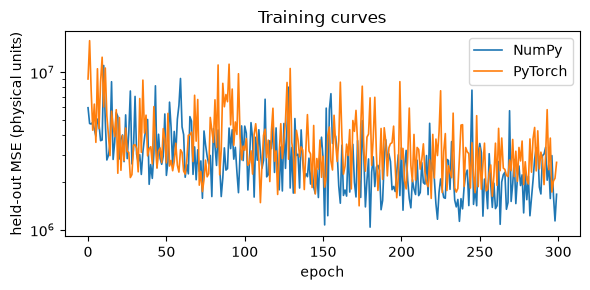

In [7]:
t0 = time.perf_counter()
np_model = MLPRegressor(hidden_layers=(128, 128), epochs=300, seed=0)
np_model.fit(X_train, y_train, X_test, y_test)
np_train_s = time.perf_counter() - t0

t0 = time.perf_counter()
torch_model = TorchMLPRegressor(hidden_layers=(128, 128), epochs=300, seed=0)
torch_model.fit(X_train, y_train, X_test, y_test)
torch_train_s = time.perf_counter() - t0

print(f"NumPy   trained in {np_train_s:.1f} s")
print(f"PyTorch trained in {torch_train_s:.1f} s")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.semilogy(np_model.history_, lw=1.2, label="NumPy")
ax.semilogy(torch_model.history_, lw=1.2, label="PyTorch")
ax.set_xlabel("epoch")
ax.set_ylabel("held-out MSE (physical units)")
ax.set_title("Training curves")
ax.legend()
plt.tight_layout()
plt.show()

The held-out curve is recorded once per epoch for plotting only. It never
feeds back into training: there is no early stopping and no tuning against
the test set, in either implementation.

## Held-out accuracy, side by side

Both models are scored by the same function, `src.ml.compare.score`, on the
same 1600 shots. MAE and RMSE are in physical units: amperes for `Ip`, metres
for the rest.

In [8]:
s_np = score(y_test, np_model.predict(X_test))
s_t = score(y_test, torch_model.predict(X_test))

print(f"{'':<5}{'R2':>18}{'MAE':>26}{'RMSE':>26}")
print(f"{'':<5}{'NumPy':>9}{'PyTorch':>9}{'NumPy':>13}{'PyTorch':>13}"
      f"{'NumPy':>13}{'PyTorch':>13}")
for name in PARAM_NAMES:
    a, b = s_np[name], s_t[name]
    print(f"{name:<5}{a['r2']:>9.4f}{b['r2']:>9.4f}"
          f"{a['mae']:>13.4g}{b['mae']:>13.4g}{a['rmse']:>13.4g}{b['rmse']:>13.4g}")
print(f"\nR2 (Ip, R0, Z0)   NumPy {r2_well(s_np):.4f}   PyTorch {r2_well(s_t):.4f}")
print(f"R2 (a)            NumPy {s_np['a']['r2']:.4f}   PyTorch {s_t['a']['r2']:.4f}")

                     R2                       MAE                      RMSE
         NumPy  PyTorch        NumPy      PyTorch        NumPy      PyTorch
Ip      0.9985   0.9976         1959         2507         2592         3272
R0      0.9844   0.9861     0.002216     0.002092     0.002847     0.002694
Z0      0.9959   0.9947     0.001561     0.001901      0.00222     0.002515
a       0.1671   0.2186      0.02835      0.02701      0.03447      0.03339

R2 (Ip, R0, Z0)   NumPy 0.9929   PyTorch 0.9928
R2 (a)            NumPy 0.1671   PyTorch 0.2186


On the three well-measured parameters the two frameworks are almost
identical (R2 0.9929 and 0.9928). Both are poor on the minor radius `a`, for
the physical reason covered in notebooks 02, 03 and 05: seen from CUTE's
sensors, all outside the vessel, widening the plasma current looks almost
exactly like moving it a few millimetres outward, so the readings cannot
separate the two. That is why R2 is reported in two parts here rather than as one
average over all four, which would sit near 0.79 and describe neither the
three good parameters nor the bad one.

Now look at `Ip`: in this run the PyTorch model's `Ip` error (MAE, the mean
absolute error) is clearly larger, about 2.5 kA against 2.0 kA. That is exactly
the kind of gap that is tempting to blame on the framework, so the next cell
checks it before anyone does.

### Is the difference real? Rerun with other seeds

One training run per framework cannot say whether a gap is the framework or
just the seed, which changes the initial weights and the batch order. So
retrain both with five seeds, same data and split, and compare the gap between
frameworks with the spread within each.

In [9]:
seeds = range(5)
by_seed = {"NumPy": [], "PyTorch": []}
for s in seeds:
    for label, cls in [("NumPy", MLPRegressor), ("PyTorch", TorchMLPRegressor)]:
        m = cls(hidden_layers=(128, 128), epochs=300, seed=s).fit(X_train, y_train)
        sc = score(y_test, m.predict(X_test))
        by_seed[label].append((r2_well(sc), sc["a"]["r2"], sc["Ip"]["mae"] / 1e3))

for label, rows in by_seed.items():
    r2w, r2a, ip = np.array(rows).T
    print(f"{label:<8} R2 (Ip, R0, Z0) {np.round(r2w, 4)}")
    print(f"{'':<8} R2 (a)          {np.round(r2a, 3)}")
    print(f"{'':<8} Ip MAE kA       {np.round(ip, 2)}   (min {ip.min():.2f}, max {ip.max():.2f})")

NumPy    R2 (Ip, R0, Z0) [0.9929 0.9921 0.9939 0.9918 0.9928]
         R2 (a)          [0.167 0.216 0.204 0.177 0.183]
         Ip MAE kA       [1.96 1.95 2.01 2.93 2.1 ]   (min 1.95, max 2.93)
PyTorch  R2 (Ip, R0, Z0) [0.9928 0.9915 0.9872 0.9923 0.9925]
         R2 (a)          [0.219 0.214 0.207 0.199 0.222]
         Ip MAE kA       [2.51 2.29 1.84 2.47 2.83]   (min 1.84, max 2.83)


The `Ip` error moves by about 50% between seeds **within each framework**
(roughly 1.8 to 2.9 kA), and the two ranges overlap almost completely. The
seed-0 PyTorch run from the table above sits in the middle of its range. So the
single-run gap was the seed, not the framework. R2 on `Ip`, `R0` and `Z0`
overlaps the same way.

One pattern is worth reporting rather than hiding: PyTorch's R2 on `a` came out
between 0.20 and 0.22 in all five runs, while NumPy's spread from 0.17 to 0.22.
The ranges overlap, and five seeds cannot tell a real difference from chance, so
the honest summary is "no evidence of a difference, and not enough runs to rule
out a small one". A single run of either framework should never be reported as
"the" accuracy of the method.

## Inference speed

Timing is easy to get wrong, so the procedure is fixed and stated:
`time_predict` makes 3 untimed warm-up calls, then 20 timed calls on the same
1600-shot batch, and reports the median divided by the batch size. Both run on
this machine's CPU with their default thread settings, in float64.

In [10]:
t_np = time_predict(np_model, X_test)
t_torch = time_predict(torch_model, X_test)
print(f"NumPy    {t_np * 1e6:6.2f} us/shot   (batch of {len(X_test)})")
print(f"PyTorch  {t_torch * 1e6:6.2f} us/shot   (batch of {len(X_test)})")
print(f"\ntraining: NumPy {np_train_s:.1f} s, PyTorch {torch_train_s:.1f} s")

NumPy      0.61 us/shot   (batch of 1600)
PyTorch    0.54 us/shot   (batch of 1600)

training: NumPy 6.0 s, PyTorch 8.0 s


Read these as "both are microseconds per shot", not as a ranking. They depend
on the batch size, the thread count, the BLAS library each framework links
against, and float64 versus float32, and changing any of those can reorder
them. What does not change is the comparison that matters from notebook 03:
either one is thousands of times faster per shot than the iterative inversion
of the same physics.

## Failure mode 1 again: sensors die

The same experiment as notebook 03: a model trained on clean signals, and one
trained with 20% of its input channels masked on every batch, then both scored
as a growing fraction of the 64 sensor channels goes dead.

Dead sensors mean the same thing as everywhere else in this repository:
`apply_dropout` replaces each dead channel with its training-set mean, a
different random set of channels per shot, and there is no separate mask
input. The PyTorch model plugs straight into that code because it exposes the
same `x_mean_` and `predict` as the NumPy one.

R2 (Ip, R0, Z0)
  dead              NumPy clean    NumPy dropout-trained            PyTorch clean  PyTorch dropout-trained
    0%                   0.9929                   0.9912                   0.9928                   0.9870
    5%                   0.9381                   0.9892                   0.9345                   0.9862
   10%                   0.8924                   0.9879                   0.8872                   0.9859
   20%                   0.7945                   0.9852                   0.7921                   0.9814
   30%                   0.7037                   0.9744                   0.7084                   0.9685

R2 (a)
  dead              NumPy clean    NumPy dropout-trained            PyTorch clean  PyTorch dropout-trained
    0%                   0.1671                   0.0563                   0.2186                   0.0710
    5%                  -1.0711                   0.0626                  -1.4998                   0.0712
   10%       

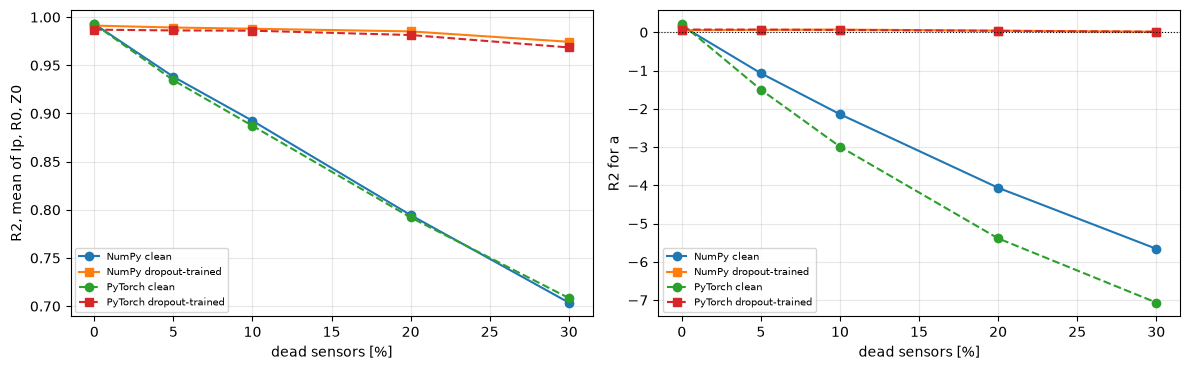

In [11]:
np_robust = MLPRegressor(hidden_layers=(128, 128), epochs=300, seed=0,
                         input_dropout=0.2).fit(X_train, y_train)
torch_robust = TorchMLPRegressor(hidden_layers=(128, 128), epochs=300, seed=0,
                                 input_dropout=0.2).fit(X_train, y_train)

def dropout_scores(m, frac, seeds=range(3)):
    """(R2 over Ip, R0, Z0; R2 for a) with a fraction of sensors dead, mean of 3 draws."""
    out = []
    for s in seeds:
        Xd = apply_dropout(X_test, m, frac, np.random.default_rng(s))
        sc = score(y_test, m.predict(Xd))
        out.append((r2_well(sc), sc["a"]["r2"]))
    return np.mean(out, axis=0)

fracs = [0.0, 0.05, 0.10, 0.20, 0.30]
models = {"NumPy clean": np_model, "NumPy dropout-trained": np_robust,
          "PyTorch clean": torch_model, "PyTorch dropout-trained": torch_robust}
curves = {k: np.array([dropout_scores(m, f) for f in fracs]) for k, m in models.items()}

for col, title in [(0, "R2 (Ip, R0, Z0)"), (1, "R2 (a)")]:
    print(title)
    print(f"{'dead':>6}" + "".join(f"{k:>25}" for k in curves))
    for i, f in enumerate(fracs):
        print(f"{f:>6.0%}" + "".join(f"{curves[k][i, col]:>25.4f}" for k in curves))
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for k, style in zip(curves, ["o-", "s-", "o--", "s--"]):
    axes[0].plot(np.array(fracs) * 100, curves[k][:, 0], style, label=k)
    axes[1].plot(np.array(fracs) * 100, curves[k][:, 1], style, label=k)
axes[0].set_ylabel("R2, mean of Ip, R0, Z0")
axes[1].set_ylabel("R2 for a")
axes[1].axhline(0, color="k", lw=0.8, ls=":")
for ax in axes:
    ax.set_xlabel("dead sensors [%]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

The finding from notebook 03 carries over, in both frameworks. For `Ip`, `R0`
and `Z0`, the clean-trained model drops to about 0.79 by 20% dead sensors,
while the dropout-trained one stays near 0.98, at a small cost when every
sensor is healthy. For `a`, the clean-trained model's R2 plunges far below
zero as sensors die (worse than always guessing the average), while the
dropout-trained model stays just above zero throughout. Because the PyTorch
rows have the same shape as the NumPy rows, the robustness result belongs to
the **training recipe**, not to the hand-written implementation, which is the
point of rerunning it.

For reference, the repository's validation report (`docs/validation_report.md`)
quotes R2 on `Ip`, `R0`, `Z0` of about 0.77 for the clean-trained model and
0.98 for a dropout-trained one at 20% dead sensors. That report trains with 15%
masking and uses different evaluation shots, so the numbers here are expected
to be close to it, not identical.

## Failure mode 2 again: error bars

Same deep ensemble as notebook 03: five members, each trained on its own data
draw with its own seed, their disagreement used as an uncertainty estimate,
then rescaled on one half of the test set and checked on the other half. The
ensemble and calibration code is shared; only the members change.

The calibration step itself is plain statistics on the predictions and stays
in NumPy. It is the same function for both ensembles, which is what makes
their coverage numbers comparable.

In [12]:
def build_ensemble(cls):
    members = []
    for k in range(5):
        Xk, yk, _ = generate_dataset(n_samples=6000, noise_frac=0.02,
                                     seed=100 * (k + 1), layout=layout)
        members.append(cls(hidden_layers=(128, 128), epochs=250, seed=k).fit(Xk, yk))
    return EnsembleSurrogate(models=members)

half = len(X_test) // 2
X_cal, y_cal = X_test[:half], y_test[:half]
X_rep, y_rep = X_test[half:], y_test[half:]

results = {}
for label, cls in [("NumPy", MLPRegressor), ("PyTorch", TorchMLPRegressor)]:
    ens = build_ensemble(cls)
    mu_c, sd_c = ens.predict_with_std(X_cal)
    mu_r, sd_r = ens.predict_with_std(X_rep)
    scales = fit_variance_scaling(y_cal, mu_c, sd_c)
    results[label] = (calibration_report(y_rep, mu_r, sd_r), scales,
                      calibration_report(y_rep, mu_r, sd_r * scales))

print(f"nominal 1-sigma coverage = {NOMINAL_1SIGMA:.3f}\n")
print(f"{'':<5}{'raw coverage':>20}{'scale factor':>20}{'calibrated coverage':>24}")
print(f"{'':<5}" + f"{'NumPy':>10}{'PyTorch':>10}" * 2 + f"{'NumPy':>12}{'PyTorch':>12}")
for j, name in enumerate(PARAM_NAMES):
    (rn, sn, cn), (rt, st, ct) = results["NumPy"], results["PyTorch"]
    print(f"{name:<5}{rn.coverage_1sigma[name]:>10.3f}{rt.coverage_1sigma[name]:>10.3f}"
          f"{sn[j]:>10.2f}{st[j]:>10.2f}"
          f"{cn.coverage_1sigma[name]:>12.3f}{ct.coverage_1sigma[name]:>12.3f}")

nominal 1-sigma coverage = 0.683

             raw coverage        scale factor     calibrated coverage
          NumPy   PyTorch     NumPy   PyTorch       NumPy     PyTorch
Ip        0.866     0.887      0.58      0.57       0.645       0.693
R0        0.580     0.630      1.28      1.14       0.677       0.690
Z0        0.825     0.849      0.70      0.62       0.691       0.667
a         0.278     0.256      3.09      3.02       0.667       0.661


The NumPy columns are notebook 03's numbers, reproduced exactly. The PyTorch
ensemble shows the same pattern. Raw spread is too wide for `Ip` and `Z0`
(raw coverage above 0.683, scale factors below 1), too narrow for `R0`, and
far too narrow for `a`. Rescaling brings every parameter near nominal on
shots the factors were not fitted on.

Two things in that table are instructive, and they point in opposite
directions.

**Some factors differ between the ensembles.** For `R0` the NumPy ensemble
needs its bars widened by 1.28, the PyTorch one by 1.14; for `Z0` it is 0.70
against 0.62. Same recipe, same data, different random initializations and
batch orders, and a noticeably different correction. So scale factors describe
**one particular trained ensemble**. They must be refitted every time the
ensemble is retrained, and never copied from one model to another.

**One factor does not differ.** For `a` both ensembles need their bars
tripled (3.09 and 3.02). That agreement is itself informative: the
overconfidence about `a` is not a quirk of one set of random seeds, it comes
from the physics. Every member, in either framework, sees the same weak
information about `a`, learns the same habit of hedging toward typical values,
and so agrees with its fellow members while all of them are wrong together.
Ensemble disagreement cannot reveal a blind spot that every member shares. Only
checking the bars against true answers, as done here, catches it.

Calibrated coverage lands between about 0.64 and 0.69 for both, not exactly on
0.683, for the reason notebook 03 gives: the factors are fitted on 800 shots
and checked on 800 different ones, so they transfer imperfectly.

What this does and does not show: coverage is measured on 800 held-out shots
from the same synthetic distribution the ensembles were trained on. It says
the rescaling works in-distribution. It says nothing about real diagnostics,
whose noise may not be independent 2% Gaussian (notebook 03, caveat 2).

## Save, reload, and use it

A PyTorch checkpoint here stores the weights, the normalization statistics,
the hyperparameters, and the **names** of the sensors and targets in order.
Loading checks those names against the current sensor configuration, so a
model trained on a different probe layout fails loudly even if it happens to
have the same number of inputs. That check is not hypothetical: when this
project switched from an invented 130-sensor layout to CUTE's real 64 channels,
every saved model had to be retrained, and the name check is what guarantees an
old file cannot be silently fed the new sensors. Files are read with `weights_only=True`, so loading a
checkpoint cannot execute code.

Saved to a temporary directory here, so running the notebook does not write
model files into the repository.

In [13]:
with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "surrogate_torch.pt")
    torch_model.save(path)
    reloaded = TorchMLPRegressor.load(path)
    same = np.array_equal(reloaded.predict(X_test), torch_model.predict(X_test))
    print(f"reloaded model gives identical predictions: {same}")

shot = X_test[0]
print("\nthe first test shot, reconstructed by the reloaded PyTorch surrogate:")
for j, (name, value) in enumerate(predict_parameters(reloaded, shot).items()):
    true = y_test[0, j]
    print(f"  {name:<3} predicted {value:>11.5g}   true {true:>11.5g}   "
          f"error {abs(value - true) / abs(true):6.1%}")

reloaded model gives identical predictions: True

the first test shot, reconstructed by the reloaded PyTorch surrogate:
  Ip  predicted       28773   true       26637   error   8.0%
  R0  predicted      0.3342   true      0.3348   error   0.2%
  Z0  predicted    0.041794   true    0.045727   error   8.6%
  a   predicted     0.11321   true     0.17544   error  35.5%


This happens to be a weak plasma, 27 kA, near the bottom of the 20 to 250 kA
training range, and it was not picked to look bad: it is simply the first
test shot. Two things stand out. The `Ip` error is 8%, far above the
typical 1 to 2% for this model. And `a` is off by more than a third, which
is no longer surprising given everything above.

The `Ip` part is not a one-off. Grouping every test shot by its current shows
a pattern:

In [14]:
ip_true = y_test[:, 0]
bands = [(20e3, 60e3), (60e3, 120e3), (120e3, 180e3), (180e3, 250e3)]
print(f"{'Ip band':>12}{'shots':>7}{'Ip MAE (kA)':>24}{'median rel. error':>26}")
print(f"{'':>19}{'NumPy':>12}{'PyTorch':>12}{'NumPy':>13}{'PyTorch':>13}")
for lo, hi in bands:
    sel = (ip_true >= lo) & (ip_true < hi)
    row = f"{lo / 1e3:>5.0f}-{hi / 1e3:<4.0f}kA{sel.sum():>7}"
    errs = [np.abs(m.predict(X_test[sel])[:, 0] - ip_true[sel])
            for m in (np_model, reloaded)]
    row += "".join(f"{e.mean() / 1e3:>12.2f}" for e in errs)
    row += "".join(f"{np.median(e / ip_true[sel]):>13.1%}" for e in errs)
    print(row)

     Ip band  shots             Ip MAE (kA)         median rel. error
                          NumPy     PyTorch        NumPy      PyTorch
   20-60  kA    283        1.22        1.69         2.6%         3.9%
   60-120 kA    413        1.73        2.50         1.5%         2.4%
  120-180 kA    403        2.07        3.52         1.1%         2.0%
  180-250 kA    501        2.47        2.16         1.0%         0.8%


Read the two halves of that table separately, because they say different
things.

- **Relative error is worst for weak plasmas.** The median relative error on
  `Ip` is about 2.6 times larger in the 20 to 60 kA band than in the 180 to
  250 kA band (NumPy).
- **Absolute error is actually smaller for weak plasmas**, about 1.2 kA against
  2.5 kA. So weak plasmas are not reconstructed "worse" in every sense. A fixed
  error of a kilo-amp or so is a much bigger fraction of a small current.

Both implementations show the same pattern, so it comes from the data, not the
framework. (The PyTorch column is somewhat worse overall because this is the
seed-0 PyTorch run, whose `Ip` error sits in the middle of its seed range but
above NumPy's seed-0 run.) The cause is in `generate_dataset`: each sensor's
noise level is set from that channel's **average** signal over the whole
dataset, so a 25 kA plasma gets the same absolute noise as a 250 kA one. A weak
plasma therefore has a lower signal-to-noise ratio, and its current is known
less precisely as a fraction of its size.

The headline `Ip` R2 above 0.99 hides this completely, because R2 is
dominated by the large spread of currents across the test set. Whether
constant absolute noise is realistic for CUTE's magnetics is not known yet
(notebook 03, caveat 2), and it decides whether low-current shots really are
this hard in relative terms.

(An earlier version of this notebook, run with an invented sensor layout, found
weak plasmas worse in absolute terms too. With CUTE's real layout that part no
longer holds, which is why the claim above is split in two.)

Bad input is rejected rather than broadcast. A sensor vector one channel short,
or one with a NaN from a failed digitizer, raises an error that says what was
expected:

In [15]:
for bad, label in [(shot[:-1], f"{len(shot) - 1} channels"), (np.where(np.arange(len(shot)) == 5, np.nan, shot), "a NaN")]:
    try:
        predict_parameters(reloaded, bad)
    except ValueError as err:
        print(f"{label:<13} -> ValueError: {err}")

63 channels   -> ValueError: signals has 63 sensor signals per sample; expected 64
a NaN         -> ValueError: signals contains 1 non-finite values (first at sample 0, column 5)


## What this notebook does and does not claim

- **It claims** the PyTorch surrogate is the same model as notebook 03's: same
  predictions from the same weights, same training steps from the same start,
  both to rounding error.
- **It claims** the notebook 03 findings (accuracy, the sensor-dropout
  tradeoff, uncalibrated raw ensemble spread fixed by rescaling) come from the
  training recipe and reproduce in a standard framework.
- **It does not claim** either framework is faster or more accurate in
  general. The timings depend on batch size, threads and precision, and the
  accuracy differences are within seed-to-seed variation over five seeds.
- **It found** that aggregate numbers hide two things in both implementations:
  an R2 averaged over all four parameters hides that the minor radius `a` is
  barely measurable from CUTE's sensors, and the headline `Ip` R2 hides a
  larger relative error for low-current plasmas, traced to how the synthetic
  noise is defined.
- **It inherits every caveat from notebook 03:** reduced physics, invented
  noise model, assumed parameter ranges, synthetic signals only (the sensor
  positions are CUTE's real ones; what they read is computed).

The practical difference is what comes next. Training on the Grad-Shafranov
dataset, trying other architectures, running on a GPU, or putting the
surrogate inside a gradient-based optimization loop are all ordinary PyTorch
from here, where in NumPy each would have meant writing more calculus by hand.